## Fred Garcia (fbg2107)
Homework Assignment 2: Profiling Small LLM Workloads

- let's start by getting the system info


In [2]:
import torch
import psutil
import transformers
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer,
    DataCollatorWithPadding,
)
from datasets import load_dataset
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import wandb
import numpy as np
import random
import platform
import time

# gpu information
print(f"GPU : {torch.cuda.get_device_name(0)}")
gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU mem: {gpu_memory:.1f} GB")
# cpu information
print(f"CPU Model: {platform.processor()}")
print(
    f"CPU Cores: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical"
)
# pytorch and transformers versions
print(f"PyTorch Version: {torch.__version__}")
print(f"Transformers Version: {transformers.__version__}")
# CUDA version (
print(f"CUDA version: {torch.version.cuda}")
# misc
print(f"Python Version: {platform.python_version()}")
print(f"system node RAM: {psutil.virtual_memory().total / (1024**3):.1f} GB")

/mnt/home/fgarcia/py_venves/hpml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/mnt/home/fgarcia/py_venves/hpml/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/mnt/home/fgarcia/py_venves/hpml/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' a

GPU : NVIDIA A100-SXM4-80GB
GPU mem: 85.2 GB
CPU Model: x86_64
CPU Cores: 64 physical, 64 logical
PyTorch Version: 2.9.0+cu128
Transformers Version: 4.57.1
CUDA version: 12.8
Python Version: 3.10.4
system node RAM: 1007.6 GB


In [3]:
# # get the wandb going
# wandb.init(project="hpml-hw2-llm")

# wandb.config.update(
#     {
#         "model_name": "distilbert-base-uncased",
#         "max_len": 256,
#         "batch_size": 32,
#         "lr": 1e-4,
#         "optimizer": "AdamW",
#         "num_workers": 2,
#         "epochs": 5,
#         "compile_mode": False,
#     }
# )

We can group runs by C, so it seems like C1 and C2 are asking for basically the same run but differnt profiling metrics?
We can just do separate runs with the same config but different profiling/logging code

In [4]:
# set seeds
seed = 144
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

load data and inspect

In [5]:
dataset = load_dataset("imdb")

In [6]:
print(f"train samples: {len(dataset['train'])}")
print(f"test samples: {len(dataset['test'])}")

# we can print the text in some training set
test_index = 144
print(f"sample review: {dataset['train'][144]['text'][:]}...")
print(f"label: {dataset['train'][144]['label']}")

train samples: 25000
test samples: 25000
sample review: I won't say this movie was bad, but it wasn't good either. I expected something good but I guess Hum Aapke Hain Kaun was much better than this. This was completely old fashioned. At every stage of this movie, I hoped for some twist and what do I get? The girl gets burned and wins her aunt's love. <br /><br />Despite of being engaged, they have to take permission for every little move they make. They are so darn shy even after so many meetings. I expected the aunt to be much more brutal than that. All she did was crib madly. <br /><br />Hey, we have kids too, but we don't watch them and have tears in our eyes always. This movie is a dream. Happy family, one cruel woman, good in-laws and a man who loves her to death. In HAHK Anupam Kher was the poor bride's father and now it's vice versa. And I somehow knew that Mohnish Behl would be in this movie. Anyway I believe I wasted my time. I give it a 2/10....
label: 0


ok it looks like we are looking at text and seeing if the movie is good or not (0 for bad, 1 for good)


the rest of the section for __Dataset and Model__




In [7]:
model_name = "distilbert-base-uncased"

# tokenaize
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
# move model to device with CUDA synchronization capability
device = torch.device("cuda")
model = model.to(device)

In [9]:
# we were told to use fixed sequence length so text will get truncated with this
MAX_LENGTH = 256
EPOCHS = 5

## C1

tokenzation (fixed length)

In [10]:
# we tocanize in this cell
# - sets truncation to true to cut off long reviews


def tokenize_function(examples):
    """tokenize with fixed max length , no padding (dynamic padding in collate_fn)"""
    return tokenizer(
        examples["text"],
        truncation=True,
        padding=False,  # dynamic padding handled in collate_fn
        max_length=MAX_LENGTH,  # fixed length for comparisons
        return_tensors=None,
    )


# we defined a function just for clarity, and apply his
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# remove text column and set format-- the words now will be turned into input_ids and attention_mask
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets.set_format("torch")

In [11]:
# use Hugging Face's built-in collator for dynamic padding
# pad to longest sequence in batch
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="longest",  # pad to longest sequence in batch
    return_tensors="pt",  # return PyTorch tensors
)

train_dataloader = DataLoader(
    tokenized_datasets["train"],
    batch_size=32,
    shuffle=True,
    collate_fn=data_collator,
    num_workers=2,  # can use >0 since DataCollator is picklable
)

test_dataloader = DataLoader(
    tokenized_datasets["test"],
    batch_size=32,
    shuffle=False,
    collate_fn=data_collator,
    num_workers=2,
)


print(f"train batches: {len(train_dataloader)}, test batches: {len(test_dataloader)}")
sample_batch = next(iter(train_dataloader))
print(
    f"sample batch - input_ids: {sample_batch['input_ids'].shape}, attention_mask: {sample_batch['attention_mask'].shape}"
)

train batches: 782, test batches: 782
sample batch - input_ids: torch.Size([32, 256]), attention_mask: torch.Size([32, 256])


In [ ]:
#######
C1_wandb_config = {
    "model_name": "distilbert-base-uncased",
    "max_len": 256,
    "batch_size": 32,
    "lr": 1e-4,
    "optimizer": "AdamW",
    "num_workers": 2,
    "epochs": EPOCHS,
    "component": "C1_baseline",
}

# create meaningful run name and group
run_name = f"bs_{C1_wandb_config['batch_size']}_lr_{C1_wandb_config['lr']}_C1"
group_name = "C1_fine_tuning"

wandb.init(
    project="hpml-hw2-llm", name=run_name, group=group_name, config=C1_wandb_config
)
########

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

train_losses = []
train_accuracies = []
test_accuracies = []


def compute_accuracy(logits, labels):
    """compute accuracy given logits and true labels"""
    predictions = torch.argmax(logits, dim=-1)
    return (predictions == labels).float().mean()


for epoch in range(EPOCHS):
    print(f"epoch {epoch + 1}/{EPOCHS}")

    # training
    model.train()
    total_train_loss = 0
    total_train_acc = 0
    train_batches = 0

    for batch in tqdm(train_dataloader, desc="training"):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss
        logits = outputs.logits

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc = compute_accuracy(logits, batch["labels"])
        total_train_loss += loss.item()
        total_train_acc += acc.item()
        train_batches += 1

    avg_train_loss = total_train_loss / train_batches
    avg_train_acc = total_train_acc / train_batches

    # evaluation
    model.eval()
    total_test_acc = 0
    test_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc="Testing"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            acc = compute_accuracy(outputs.logits, batch["labels"])
            total_test_acc += acc.item()
            test_batches += 1

    avg_test_acc = total_test_acc / test_batches

    # store metrics needed
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)
    test_accuracies.append(avg_test_acc)

    # log to W&B
    wandb.log(
        {
            "train/loss": avg_train_loss,
            "train/accuracy": avg_train_acc,
            "test/accuracy": avg_test_acc,
            "epoch": epoch + 1,
        }
    )

    print(
        f"train Loss: {avg_train_loss:.4f}, train Acc: {avg_train_acc:.4f}, test Acc: {avg_test_acc:.4f}"
    )

wandb: Currently logged in as: fgarcia4 (fgarcia4-columbia-uni) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


epoch 1/5


Testing: 100%|██████████| 782/782 [00:42<00:00, 18.19it/s]


train Loss: 0.3084, train Acc: 0.8691, test Acc: 0.9009
epoch 2/5


Testing: 100%|██████████| 782/782 [00:42<00:00, 18.20it/s]


train Loss: 0.1703, train Acc: 0.9367, test Acc: 0.8945
epoch 3/5


Testing: 100%|██████████| 782/782 [00:43<00:00, 18.18it/s]


train Loss: 0.0870, train Acc: 0.9703, test Acc: 0.8848
epoch 4/5


training:  38%|███▊      | 297/782 [00:48<01:18,  6.15it/s]

### Figure F1

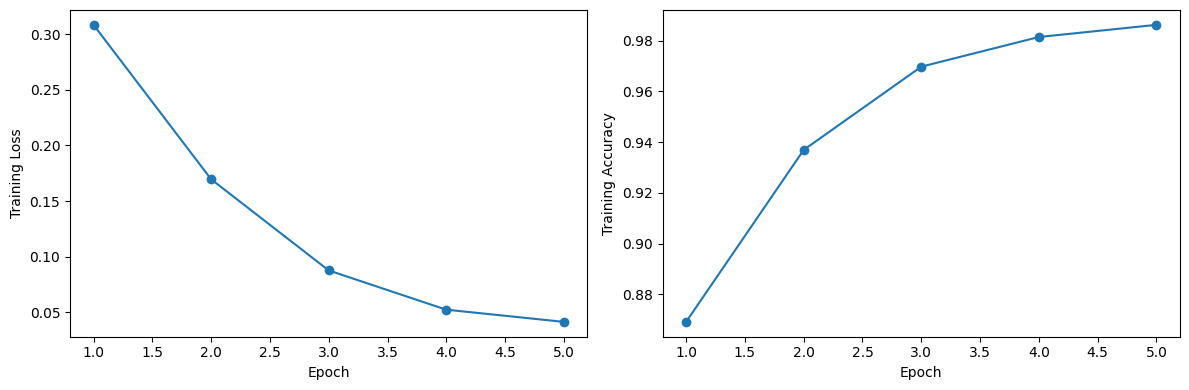

In [ ]:
# This creates Figure F1
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: Training loss decreasing over epochs
ax[0].plot(range(1, EPOCHS + 1), train_losses, marker="o")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Training Loss")


# Right plot: Training and test accuracy increasing over epochs
ax[1].plot(range(1, EPOCHS + 1), train_accuracies, marker="o")
# ax[1].plot(range(1, 6), test_accuracies, marker="s", label="test accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Training Accuracy")
# ax[1].legend()


plt.tight_layout()
plt.savefig("./C1_F1.png", dpi=300, bbox_inches="tight")
plt.show()

### Table T1

In [ ]:
table_t1 = pd.DataFrame(
    {
        "Epoch": range(1, EPOCHS + 1),
        "Train Loss": [f"{loss:.4f}" for loss in train_losses],
        "Train Accuracy": [f"{acc:.4f}" for acc in train_accuracies],
        "Test Accuracy": [f"{acc:.4f}" for acc in test_accuracies],
    }
)
table_t1
wandb.log({"C2_Table_T1": wandb.Table(dataframe=table_t1)})
wandb.finish()

epoch,▁▃▅▆█
test/accuracy,█▆▅▃▁
train/accuracy,▁▅▇██
train/loss,█▄▂▁▁
epoch,5
test/accuracy,0.86749
train/accuracy,0.98629
train/loss,0.04148


## C2


we don't need the test eval loop according to post #107

In [ ]:
######
C2_wandb_config = {
    "model_name": "distilbert-base-uncased",
    "sequence_length": 256,
    "batch_size": 32,
    "learning_rate": 1e-4,
    "optimizer": "AdamW",
    "number_dataloader_workers": 2,
    "epochs": 5,
    "device": "cuda",
    "torch_compile_enabled": False,
}
group_name = "C2_baseline_timing"
run_name = f"bs_{C2_wandb_config['batch_size']}_lr_{C2_wandb_config['learning_rate']}_C2"  # same config as C1 for fair timing comparison
wandb.init(
    project="hpml-hw2-llm", name=run_name, group=group_name, config=C2_wandb_config
)
######


# measuring: (a) data-loading time, (b) training compute time, (c) total epoch time
epoch_times = []  # (c) total training epoch time
data_loading_times = []  # (a) data loading time per epoch
compute_times = []  # (b) compute time per epoch (forward + backward + optimizer)

for epoch in range(5):
    print(f"Epoch {epoch + 1}/5")

    # training phase - with all timing components
    model.train()
    total_train_loss = 0
    total_train_acc = 0
    train_batches = 0

    # timing variables for this epoch's TRAINING
    epoch_data_loading_time = 0  # (a) Data loading time
    epoch_compute_time = 0  # (b) Compute time

    # start epoch timer (c) Total epoch time
    epoch_start_time = time.time()

    for batch in tqdm(train_dataloader, desc=f"Timing Epoch {epoch+1}"):
        # data loading time
        data_load_start = time.time()

        batch = {k: v.to(device) for k, v in batch.items()}

        # CUDA synchronization for accurate timing
        torch.cuda.synchronize()

        data_load_end = time.time()
        epoch_data_loading_time += data_load_end - data_load_start

        # (b) COMPUTE TIME (forward + backward + optimizer)
        compute_start = time.time()

        # forward pass
        outputs = model(**batch)
        loss = outputs.loss
        logits = outputs.logits

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        torch.cuda.synchronize()  # CUDA sync for accurate timing

        compute_end = time.time()
        epoch_compute_time += compute_end - compute_start

        # metrics (not timed - part of compute overhead)
        acc = compute_accuracy(logits, batch["labels"])
        total_train_loss += loss.item()
        total_train_acc += acc.item()
        train_batches += 1

    # end epoch timer for training only
    epoch_end_time = time.time()
    epoch_total_time = epoch_end_time - epoch_start_time

    # timing consistency check (data + compute ~ total)
    timing_sum = epoch_data_loading_time + epoch_compute_time
    timing_diff = epoch_total_time - timing_sum
    print(
        f"   Timing check: Data+Compute={timing_sum:.2f}s, Total={epoch_total_time:.2f}s, Diff={timing_diff:.2f}s"
    )

    # store timing metrics
    epoch_times.append(epoch_total_time)
    data_loading_times.append(epoch_data_loading_time)
    compute_times.append(epoch_compute_time)

    # calculate training metrics
    avg_train_loss = total_train_loss / train_batches
    avg_train_acc = total_train_acc / train_batches

    # evaluation phase - NO TIMING FOR C2
    model.eval()
    total_test_acc = 0
    test_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc=f"Testing Epoch {epoch+1}"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            acc = compute_accuracy(outputs.logits, batch["labels"])
            total_test_acc += acc.item()
            test_batches += 1

    avg_test_acc = total_test_acc / test_batches

    # log to W&B - TRAINING TIMING ONLY
    wandb.log(
        {
            "train/loss": avg_train_loss,
            "train/accuracy": avg_train_acc,
            "test/accuracy": avg_test_acc,
            "time/data_loading": epoch_data_loading_time,  # (a)
            "time/compute": epoch_compute_time,  # (b)
            "time/epoch_total": epoch_total_time,  # (c)
            "epoch": epoch + 1,
        }
    )

    print(f"Epoch {epoch+1} Complete")
    print(f"   (a) Data Loading: {epoch_data_loading_time:.2f}s")
    print(f"   (b) Compute Time: {epoch_compute_time:.2f}s")
    print(f"   (c) Total Epoch:  {epoch_total_time:.2f}s")
    print(f"   Test Accuracy:    {avg_test_acc:.4f}")

Epoch 1/5


Timing Epoch 1: 100%|██████████| 782/782 [02:07<00:00,  6.11it/s]


   Timing check: Data+Compute=124.71s, Total=128.01s, Diff=3.30s


Testing Epoch 1: 100%|██████████| 782/782 [00:43<00:00, 18.12it/s]


Epoch 1 Complete
   (a) Data Loading: 0.14s
   (b) Compute Time: 124.57s
   (c) Total Epoch:  128.01s
   Test Accuracy:    0.8744
Epoch 2/5


...

Epoch 4 Complete
   (a) Data Loading: 0.12s
   (b) Compute Time: 124.62s
   (c) Total Epoch:  127.72s
   Test Accuracy:    0.8549
Epoch 5/5


Timing Epoch 5: 100%|██████████| 782/782 [02:08<00:00,  6.11it/s]


   Timing check: Data+Compute=124.71s, Total=128.07s, Diff=3.36s


Testing Epoch 5: 100%|██████████| 782/782 [00:42<00:00, 18.19it/s]

Epoch 5 Complete
   (a) Data Loading: 0.14s
   (b) Compute Time: 124.58s
   (c) Total Epoch:  128.07s
   Test Accuracy:    0.8371


### Table T2 

In [ ]:
# Create Table T2: Per-epoch timing metrics
table_t2 = pd.DataFrame(
    {
        "Epoch": range(1, 6),
        "Data Loading Time (s)": [f"{t:.4f}" for t in data_loading_times],
        "Compute Time (s)": [f"{t:.4f}" for t in compute_times],
        "Total Epoch Time (s)": [f"{t:.4f}" for t in epoch_times],
    }
)
table_t2

# Save table
# table_t2.to_csv('C2_timing_metrics.csv', index=False)

,Epoch,Data Loading Time (s),Compute Time (s),Total Epoch Time (s)
0,1,0.1358,124.5702,128.0062
1,2,0.1361,124.6141,127.8744
2,3,0.1184,124.5608,127.6180
3,4,0.1245,124.6212,127.7170
4,5,0.1383,124.5752,128.0686


In [ ]:
wandb.log({"C2_Table_T2": wandb.Table(dataframe=table_t2)})
wandb.finish()

Error: You must call wandb.init() before wandb.log()

### Figure F2

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=300)

# Create stacked bars for training timing only
epochs = range(1, 6)
bar_width = 0.6

bars1 = ax.bar(
    epochs,
    data_loading_times,
    bar_width,
    label="Data Loading",
    alpha=0.8,
)
bars2 = ax.bar(
    epochs,
    compute_times,
    bar_width,
    bottom=data_loading_times,
    label="Compute",
    alpha=0.8,
)

# Add labels and formatting
ax.set(xlabel="Epoch", ylabel="Time (seconds)", yscale="log")

ax.set_xticks(epochs)
ax.legend()


# add compute percentage labels on bars
for i, (data_time, compute_time) in enumerate(zip(data_loading_times, compute_times)):
    total_time = data_time + compute_time
    compute_pct = (compute_time / total_time) * 100
    ax.text(
        i + 1,
        data_time + compute_time / 2,
        f"{compute_pct:.4f}%",
        ha="center",
        va="center",
        fontsize=9,
        color="white",
    )


plt.savefig("C2_F2.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# Test different num_workers values
num_workers_list = [0, 2, 4, 8]
results = []

for num_workers in num_workers_list:
    print(f"testing num_workers = {num_workers}")
    # W&B Configuration for this run
    wandb_config = {
        "model_name": "distilbert-base-uncased",
        "sequence_length": 256,
        "batch_size": 32,
        "learning_rate": 1e-4,
        "optimizer": "AdamW",
        "number_dataloader_workers": num_workers,  # Varied parameter
        "epochs": 5,
        "device": "cuda",
        "torch_compile_enabled": False,
        "component": "C3_dataloader",
    }

    run_name = f"bs_32_lr_1e-4_workers_{num_workers}"
    group_name = "C3_num_workers_compare"

    wandb.init(
        project="hpml-hw2-llm", name=run_name, group=group_name, config=wandb_config
    )

    # recreate DataLoaders with current num_workers
    train_dataloader = DataLoader(
        tokenized_datasets["train"],
        batch_size=32,
        shuffle=True,
        collate_fn=data_collator,
        num_workers=num_workers,  # This is what we're testing
    )

    # reinitialize model and optimizer for fair comparison
    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=2
    )
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

    # training metrics storage for this run
    epoch_times = []
    data_loading_times = []
    compute_times = []
    train_accuracies = []
    test_accuracies = []

    # training loop with timing (similar to C2)
    for epoch in range(5):
        print(f"Epoch {epoch + 1}/5 - workers={num_workers}")

        # Training phase with timing
        model.train()
        epoch_data_loading_time = 0
        epoch_compute_time = 0
        total_train_acc = 0
        train_batches = 0

        epoch_start_time = time.time()

        for batch in tqdm(train_dataloader, desc=f"workers={num_workers}"):
            # data loading time
            data_load_start = time.time()
            batch = {k: v.to(device) for k, v in batch.items()}
            torch.cuda.synchronize()
            data_load_end = time.time()
            epoch_data_loading_time += data_load_end - data_load_start

            # compute time
            compute_start = time.time()
            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            torch.cuda.synchronize()
            compute_end = time.time()
            epoch_compute_time += compute_end - compute_start

            # metrics
            acc = compute_accuracy(logits, batch["labels"])
            total_train_acc += acc.item()
            train_batches += 1

        epoch_end_time = time.time()
        epoch_total_time = epoch_end_time - epoch_start_time

        # store metrics
        epoch_times.append(epoch_total_time)
        data_loading_times.append(epoch_data_loading_time)
        compute_times.append(epoch_compute_time)
        train_accuracies.append(total_train_acc / train_batches)

        # quick test evaluation (no timing)
        model.eval()
        total_test_acc = 0
        test_batches = 0
        with torch.no_grad():
            for batch in test_dataloader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                acc = compute_accuracy(outputs.logits, batch["labels"])
                total_test_acc += acc.item()
                test_batches += 1

        test_accuracies.append(total_test_acc / test_batches)

        # Log to W&B
        wandb.log(
            {
                "train/accuracy": train_accuracies[-1],
                "test/accuracy": test_accuracies[-1],
                "time/data_loading": epoch_data_loading_time,
                "time/compute": epoch_compute_time,
                "time/epoch_total": epoch_total_time,
                "epoch": epoch + 1,
            }
        )

        print(
            f"   Time: Data={epoch_data_loading_time:.2f}s, Compute={epoch_compute_time:.2f}s, Total={epoch_total_time:.2f}s"
        )
        print(
            f"   Acc: Train={train_accuracies[-1]:.4f}, Test={test_accuracies[-1]:.4f}"
        )

    # store results for this num_workers
    avg_epoch_time = np.mean(epoch_times)
    avg_data_loading_time = np.mean(data_loading_times)
    avg_compute_time = np.mean(compute_times)
    final_train_acc = train_accuracies[-1]
    final_test_acc = test_accuracies[-1]

    results.append(
        {
            "num_workers": num_workers,
            "avg_epoch_time": avg_epoch_time,
            "avg_data_loading_time": avg_data_loading_time,
            "avg_compute_time": avg_compute_time,
            "final_train_accuracy": final_train_acc,
            "final_test_accuracy": final_test_acc,
        }
    )

    print(f"num_workers={num_workers} Summary:")
    print(f"avg Epoch Time: {avg_epoch_time:.2f}s")
    print(
        f"avg Data Loading: {avg_data_loading_time:.2f}s ({avg_data_loading_time/avg_epoch_time*100:.1f}%)"
    )
    print(f"final Test Accuracy: {final_test_acc:.4f}")

In [ ]:
table_t3 = pd.DataFrame(results)
table_t3

In [ ]:
table_t3_formatted = pd.DataFrame(
    {
        "Num Workers": table_t3["num_workers"],
        "Avg Epoch Time (s)": [f"{t:.2f}" for t in table_t3["avg_epoch_time"]],
        "Avg Data Loading Time (s)": [
            f"{t:.2f}" for t in table_t3["avg_data_loading_time"]
        ],
        "Avg Compute Time (s)": [f"{t:.2f}" for t in table_t3["avg_compute_time"]],
        "Data Loading %": [
            f"{(data/total)*100:.1f}%"
            for data, total in zip(
                table_t3["avg_data_loading_time"], table_t3["avg_epoch_time"]
            )
        ],
        "Final Train Accuracy": [
            f"{acc:.4f}" for acc in table_t3["final_train_accuracy"]
        ],
        "Final Test Accuracy": [
            f"{acc:.4f}" for acc in table_t3["final_test_accuracy"]
        ],
    }
)


table_t3_formatted.to_csv("C3_num_workers_comparison.csv", index=False)


wandb.init(
    project="hpml-hw2-llm", name="C3_summary_table", group="C3_num_workers_compare"
)
wandb.log({"C3_Table_T3": wandb.Table(dataframe=table_t3_formatted)})
wandb.finish()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=300)


ax.plot(
    table_t3["num_workers"],
    table_t3["avg_epoch_time"],
    "bo-",
    linewidth=2,
    markersize=8,
)
ax.set_xlabel("Number of DataLoader Workers")
ax.set_ylabel("Average Epoch Time (seconds)")
ax.set_title("C3: Average Epoch Time vs Number of Workers")
ax.grid(True, alpha=0.3)
ax.set_xticks(table_t3["num_workers"])


for i, (workers, time_val) in enumerate(
    zip(table_t3["num_workers"], table_t3["avg_epoch_time"])
):
    ax.annotate(
        f"{time_val:.1f}s",
        (workers, time_val),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig("C3_num_workers_performance.png", dpi=300, bbox_inches="tight")
plt.show()